# Homework10

Exercises with text processing and NLP modeling

# Sofía :)

## Goals

- Understand similarities and differences between the processes of working with text, images and tabular data
- Practice with different methods of encoding and modeling text data
- See different methods for extracting information or patterns from text datasets

### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework.

In [3]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/text_utils.py

In [4]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from data_utils import display_silhouette_plots, object_from_json_url
from text_utils import get_top_words

You can tell it's gonna be a good homework from the number of imports.
# 🙃

## Cheat Sheet

There are lots of conversions in this homework between lists, strings, vectors, scores, etc...

This list can help as a quick reference for the names of the functions and what they expect as input, and produce as output.

These all operate on lists of _something_ and return lists of _something else_. But, here, let's just focus on the _type_ of the elements that go in these lists. Most of them will work on single elements, but not all.

`TFIDF.fit_transform(string)` / `TFIDF.transform(string)` : string -> sparse vector

`TFIDF.inverse_transform(vector)` : sparse vector -> list of words (NOT a string)

`TFIDF.get_feature_names_out()` : None -> list of words (vocab of dataset)

`TFIDF.get_feature_names_out()[idx]` : int (column index / word id) -> word

`vector.toarray()` : vector -> regular array

`get_top_words(vector, vocab, n_words=N)` : vector + list of all words + int -> list of top-N words in vector

`argsort(metric)` : list of floats -> list of int indexes

For example:

To get the words in a sentence ordered by importance (most important first), we have to turn a string into a vector, then the vector into a regular list of scores, then the list into indexes, and, finally, fetch words from our vocab list using these indexes.

```py
sentence = "a sentence goes here"
num_words = len(sentence.split(" "))
sentence_vct = TFIDF.transform([sentence])
sentence_vct_list = sentence_vct.toarray()
idx_by_importance = argsort(sentence_vct_list, reverse=True)[:num_words]
TFIDF.get_feature_names_out()[idx_by_importance]
```

For this particular example we could've used the `get_top_words()` function to get words ordered by importance:

```py
sentence = "a sentence goes here"
num_words = len(sentence.split(" "))

get_top_words(
  TFIDF.transform([sentence]),
  TFIDF.get_feature_names_out(),
  n_words=num_words
)
```

## Have protein, need seasoning

Let's create a model to help us season our foods. In the end, what we want is a model that receives a short list of ingredients and returns a list of seasonings or complementary ingredients for our original ingredients list.

In order to do that we need a dataset of recipes. We'll load that into a text dataset where each recipe is a document and the ingredients are our document *tokens*.

Let's take a look at the recipe dataset and become familiar with the data and how it's organized.

We'll load our recipes and do a bit of exploratory data analysis to look for patterns first to see if this kind of modeling makes any sense.

### Load Data

Here's our dataset. Let's load it into an object for inspection:

In [5]:
DATA_PATH = "https://raw.githubusercontent.com/PSAM-5020-2026S-A/5020-utils/refs/heads/main/datasets/text/recipes/recipes_min16.json"
recipes_obj = object_from_json_url(DATA_PATH)

### Look at Data

How's the data organized?

How many recipes do we have?

Do all recipes have the same number of ingredients?

Anything else stand out about the data?

In [6]:
import pandas as pd

# TODO: Look at Data here
type(recipes_obj), type(recipes_obj[0]), recipes_obj[0]

# preview table
recipes_df = pd.DataFrame(recipes_obj)
display(recipes_df.head(10))

# TODO: How many recipes
num_recipes = len(recipes_obj)
print(f"Number of recipes: {num_recipes}")

# TODO: How many ingredients do the shortest and longest recipes have?
ingredient_counts = [len(recipe["ingredients"]) for recipe in recipes_obj]
min_ingredients = min(ingredient_counts)
max_ingredients = max(ingredient_counts)

print(f"Shortest recipe has {min_ingredients} ingredients")
print(f"Longest recipe has {max_ingredients} ingredients")

,id,ingredients
0,18009,"[raisins, baking powder, egg, sugar, milk, flour]"
1,35687,"[parmesan cheese, salt, cornmeal, black pepper..."
2,38527,"[salt, corn starch, butter, lemon juice, bakin..."
3,41217,"[corn starch, orange juice, rice, ginger, vine..."
4,42969,"[cilantro, rice, ginger, garlic, yogurt, curry..."
5,44883,"[mozzarella cheese, salt, parmesan cheese, ric..."
6,19001,"[salt, rice, chili, olives, jack cheese, chedd..."
7,16526,"[salt, rice, vegetable oil, egg, cold water, b..."
8,47453,"[salt, turmeric, rice, butter, water]"
9,42478,"[salt, potatoes, shallots, vinegar, lentils, b..."


Number of recipes: 5015
Shortest recipe has 5 ingredients
Longest recipe has 27 ingredients


### Create Input Features

Our dataset doesn't really have to be a `DataFrame` here. It can, but it doesn't have to be.

Each recipe right now is described as a list of ingredients, but what we really want is a list of *sentences*, where each *sentence* is a Python `string` with all of the ingredients for a given recipe.

Instead of:<br>```["salt", "baking soda", "water", "mushroom"]```,

we want:<br>```"salt baking soda water mushroom"```

The `join()` function might help.

Another thing to consider is wether we want to do anything special about multi-word ingredients, like *baking soda*.

Do we want to let our vectorizer split that into two tokens, or do we want to guarantee that *baking* and *soda* always stay together? 

In [7]:
# TODO: turn list of objects into list of strings
recipes = [" ".join(recipe["ingredients"]) for recipe in recipes_obj]

# preview table just to make sureeee
recipes_str_df = pd.DataFrame({"recipe_str": recipes})
display(recipes_str_df.head(10))

print(recipes[0])
print(f"total recipe strings: {len(recipes)}")

,recipe_str
0,raisins baking powder egg sugar milk flour
1,parmesan cheese salt cornmeal black pepper sau...
2,salt corn starch butter lemon juice baking pow...
3,corn starch orange juice rice ginger vinegar v...
4,cilantro rice ginger garlic yogurt curry powde...
5,mozzarella cheese salt parmesan cheese rice pa...
6,salt rice chili olives jack cheese cheddar che...
7,salt rice vegetable oil egg cold water butterm...
8,salt turmeric rice butter water
9,salt potatoes shallots vinegar lentils black p...


raisins baking powder egg sugar milk flour
total recipe strings: 5015


### Encode Data

The fun part.

Let's vectorize our list of ingredient strings into a sparse document matrix using `CountVectorizer` or `TfidfVectorizer`.

The resulting matrix will have one row for each recipe, and the columns will encode the ingredients.

In [8]:
# TODO: Vectorize ingredients from our recipe list
TFIDF = TfidfVectorizer()
recipes_vct = TFIDF.fit_transform(recipes)
print(f"Vectorized recipes shape: {recipes_vct.shape}")

# TODO: How many words are in our vocabulary?
vocab_size = len(TFIDF.get_feature_names_out())
print(f"Voc size: {vocab_size}")

Vectorized recipes shape: (5015, 464)
Voc size: 464


### Cluster Data

Now that we have our recipes/documents vectorized we can study them a little bit, and look for patterns.

What happens if we cluster our recipes ? What do the cluster centers represent ?

When might this be useful ?

<span style="color:hotpink">
When we cluster the recipes, we put togheter recipes that use kinda similar ingredients.<br>
The cluster center is like the “average recipe” of that group. It shows the most importent ingredients for that cluster style.<br>
</span>

<span style="color:blue">
This can be usefull to:<br>
- find groups of recipes with no labels<br>
- understand common ingredient patterns<br>
- recomend new recipes or ingrediants<br>
- make search faster by looking in the right group first<br>
- find strange recipes that dont fit well in any group<br>
</span>

In [9]:
# TODO: cluster recipes
mClust = KMeans(n_clusters=8, random_state=800)
recipe_clusters = mClust.fit_predict(recipes_vct)
cluster_centers = mClust.cluster_centers_

#preview of cluster assignments for the first recipes and a table with cluster sizes
display(pd.DataFrame({"cluster": recipe_clusters}).head(20))
display(pd.Series(recipe_clusters).value_counts().sort_index().to_frame(name="n_recipes"))

,cluster
0,7
1,3
2,7
3,6
4,4
5,3
6,1
7,7
8,4
9,0


,n_recipes
0,603
1,431
2,481
3,683
4,1441
5,472
6,206
7,698


### Cluster Centers

Use the `get_top_words()` function to decode the `cluster_centers` back into ingredients.

In [10]:
# TODO: Look at cluster centers
vocab = TFIDF.get_feature_names_out()
get_top_words(mClust.cluster_centers_, vocab, n_words=8)

[['chicken', 'pepper', 'broth', 'onion', 'rice', 'thyme', 'garlic', 'salt'],
 ['tortilla', 'cheese', 'cheddar', 'cream', 'sour', 'salsa', 'chili', 'onion'],
 ['sauce', 'soy', 'sesame', 'oil', 'ginger', 'sugar', 'garlic', 'rice'],
 ['cheese',
  'parmesan',
  'olive',
  'pepper',
  'mozzarella',
  'basil',
  'oil',
  'garlic'],
 ['pepper', 'oil', 'salt', 'olive', 'garlic', 'onion', 'lemon', 'tomatoes'],
 ['lime', 'juice', 'cilantro', 'chili', 'fish', 'onion', 'sauce', 'garlic'],
 ['starch', 'corn', 'sauce', 'soy', 'oil', 'ginger', 'sesame', 'pepper'],
 ['flour', 'egg', 'sugar', 'baking', 'butter', 'milk', 'vanilla', 'salt']]

### Interpretation

<span style="color:hotpink">
What do these cluster centers represent ?<br>
Is there anything interesting about recipe cluster centers ?<br>
</span>

<span style="color:lightblue;">
The cluster centers represent a kind of average recipe for each cluster.<br>
They show the ingrediants with higher weight that define each recipe group.<br>
<br>
Yes, something interessting is that some centers look like clear food styles (for example baking or cheesy dishes).<br>
So the model is not random, it is finding real patterns in the recipes.<br>
</span>

### Plot Clusters

Let's plot our clusters to see if we have to adjust any of the clustering parameters.

Since we can't plot in $500$ dimensions, we should use `TruncatedSVD` to look at our clusters in $2D$ and $3D$.

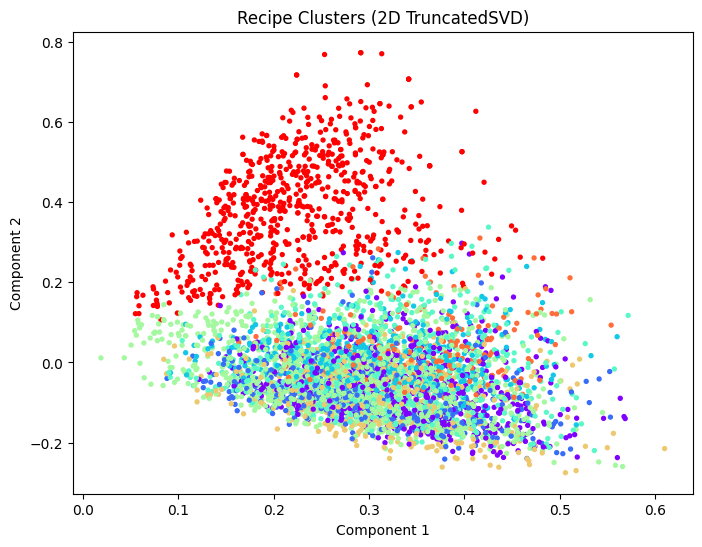

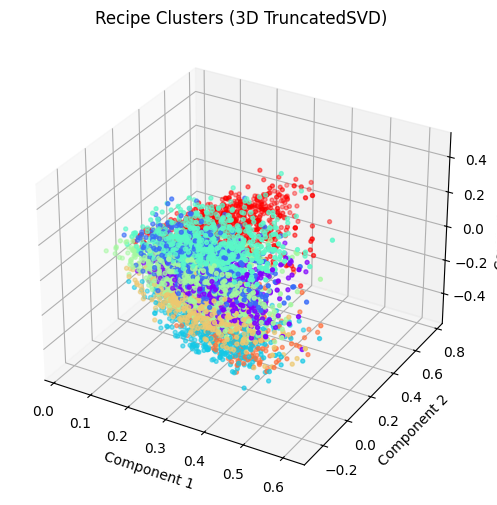

In [14]:
# TODO: TruncatedSVD to reduce the dimensions of our feature space
svd_2d = TruncatedSVD(n_components=2, random_state=800)
recipes_2d = svd_2d.fit_transform(recipes_vct)

svd_3d = TruncatedSVD(n_components=3, random_state=800)
recipes_3d = svd_3d.fit_transform(recipes_vct)

# TODO: plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(recipes_2d[:, 0], recipes_2d[:, 1], c=recipe_clusters, s=8, cmap=cm.rainbow)
plt.title("Recipe Clusters (2D TruncatedSVD)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(recipes_3d[:, 0], recipes_3d[:, 1], recipes_3d[:, 2], c=recipe_clusters, s=8, cmap=cm.rainbow)
ax.set_title("Recipe Clusters (3D TruncatedSVD)")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.set_zlabel("Component 3")
plt.show()

### Interpretation

<span style="color:hotpink">
What does the graph look like ?<br>
Are the clusters well-separated ?
</span>

<span style="color:lightgreen;">
The graph looks like one main cloud with some groups inside it (i dont enjoy how long the code is but it's prettyyyy).<br>
In 2D we can see one cluster more separate on top, and many others mixed togheter in the bottom area.<br>
In 3D it looks a bit better, but still there is overlap between several clusters.<br>
<br>
So, clusters are not fully well separated, only partialy separated.<br>
</span>

### Plot Silhouette Plots

We can also check the quality of our clustering by looking at the silhouette plots that we get from calling:<br>
`display_silhouette_plots(vectors, clusters)`.

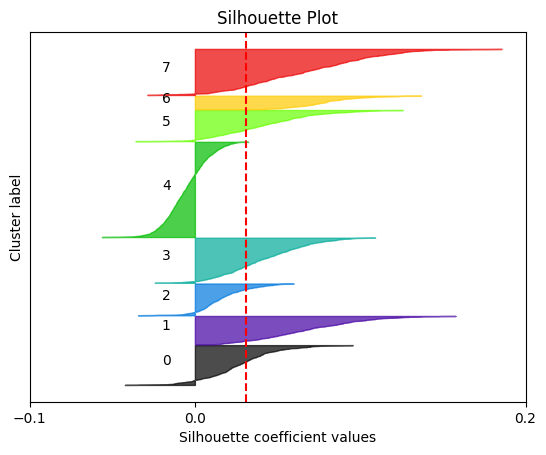

In [15]:
display_silhouette_plots(recipes_vct, recipe_clusters)

### Interpretation

<span style="color:hotpink">
How many clusters did you end up with ?<br>
How do they look ?<br>
</span>

<span style="color:lightgreen;">
We ended up with 8 clusters.<br>
They look okay, but not super clean i think.<br>
One group looks more separated, and many others are mixed and kind of overlaped.<br>
So the clustering works, but the separation is only medium and not perfect.<br>
</span>

## Recipe Completion

Ok. On to the main event.

Let's create some recipes.

We'll do this using a technique similar to what is used for movie/product recommendations. Given an initial set of ingredients, we'll look at recipes that have similar ingredients and "recommend" additional ingredients.

We already have all of the recipes in our dataset encoded as `tf-idf` vectors. The rest of our algorithm will be something like:
1. Start with an initial set of ingredients
2. Encode ingredients
3. Find a set of recipes that are similar to our list of ingredients
4. Find common ingredients that are in the similar recipes, but not in our list of ingredients
5. Pick representative ingredient to add to recipe
6. Repeat

Let's start.

### 1. Initial list of ingredients

This is just a string with ingredients:

In [16]:
recipe_seed_str = "pasta" 

### 2. Encode ingredients

Transform the string into a `tf-idf` vector using the `transofrm()` function from the pre-fitted `TfidfVectorizer` object:

In [17]:
# TODO: transform string into sparse vector
recipe_seed_vct = TFIDF.transform([recipe_seed_str])

### 3. Find similar recipes

The meat of the algorithm. No pun intended.

In order to find similar recipes, we'll first calculate the distance between our current list of ingredients and all recipes in our dataset.

We can start with euclidean distance and later try other kinds, but the overall processing will be the same:

1. Start with an empty list to store distances
2. Loop over the `tf-idf` recipe vectors and for each vector:
   1. Subtract the ingredient list
   2. Square the difference (to square a sparse matrix `A`, use `A.multiply(A)`)
   3. Sum the terms of the result
   4. Take the square root of the sum
   5. Append to distance list
3. Find the indices of the smallest distances (this operation is called `argsort` and will give us the indices of the recipes that are most similar to our list of ingredients)
4. Check the recipes to see if they are indeed similar (`inverse_transform()` the vectors at the indices calculated above)

In [18]:
# argsort a list (get sequence of indices that would sort the list)
# https://stackoverflow.com/a/3382369
def argsort(L, reverse=False):
  L = L[0] if len(L) == 1 else L
  return sorted(range(len(L)), key=L.__getitem__, reverse=reverse)

In [19]:
# TODO: list to keep distances
recipe_distances = []

# TODO: loop over vectors and append euclidean distances to list
for i in range(recipes_vct.shape[0]):
    diff = recipes_vct[i] - recipe_seed_vct
    dist = (diff.multiply(diff).sum()) ** 0.5
    recipe_distances.append(dist)

# TODO: argsort list of distances to find indices of similar recipes
similar_recipe_idx = argsort(recipe_distances)

# TODO: check first 4 recipes
top4_idx = similar_recipe_idx[:4]
print("4 similar recipe:", top4_idx)
for idx in top4_idx:
    print(recipes[idx])

4 similar recipe: [129, 1041, 2385, 1825]
salt pasta black pepper cheddar cheese milk
salt wine pasta tomatoes garlic basil olive oil
parmesan cheese parsley pasta chicken broth egg
pasta butter garlic tomato sauce mushroom olive oil


<span style="color:lightgreen;">
when I enter a dish like lasagna, ravioli, or paella, it always gives me the same answer.

<span style="color:white;">4 similar recipe: [306, 1262, 4243, 19]<br>
cilantro udon beansprouts chili lime rind peanut cooking spray red curry paste soy sauce redpepper lime juice shrimp onion sugar<br>
salt cilantro turmeric cumin seed lemon juice ginger peas tomatoes asafoetida vegetable oil garlic chile pepper red chile pepper water<br>
salt rice egg celery cooking spray garlic onion yogurt egg onion cheddar cheese andouille redpepper hot sauce<br>
salt parsley celery pepper bell pepper garlic onion turkey onion sausage bay oil flour<br>

<span style="color:lightgreen;">But if I enter something like tofu, tomato, or pasta, the response changes depending on the word. At the beginning, I thought I had to choose a dish.<br>
</span>

### 4. Find ingredients to recommend

We have a way to get a set of similar recipes with similar ingredients, and now want to find a *meaningful*, or *representative*, ingredient to add to our ingredients list.

Let's consider ingredients in the $16$ most similar recipes. What we are trying to do is find an ingredient that is in a lot of these recipes, but not yet in our list of ingredients.

There are many possible ways of doing this. We could count the number of times different ingredients show up in these $16$ recipes using Python dictionaries and/or sets, but what we're trying to do here is very similar to what a `TfidfVectorizer` does: calculate relative importance of terms in a series of documents.

Let's re-encode these $16$ recipes using their own separate `TfidfVectorizer`, then sum the importance of each ingredient and look at ingredients with the highest importance scores.

We could re-use the vectors/scores from the original `TfidfVectorizer`, but they're gonna be influenced by the relative frequencies of all of the ingredients that showed up in all of the recipes. Using a separate vectorizer is a little bit more precise.

The steps we need to take are:

1. Separate the $16$ recipes most similar to our list of ingredients
   1. We have lots of representations of our recipes, but `recipes` (list of strings) might be the easiest one to use here
2. Create a new `TfidfVectorizer` and encode the $16$ recipes
3. Sum the resulting vectors by column to get overall importance scores for each ingredient/token
4. Convert resulting vector to a list using `A.tolist()[0]`
5. `argsort` the importance scores to get sequence of ingredient indices ordered from most to least important
6. Find the most important ingredient that isn't on the ingredient list

In [23]:
# TODO: Get 16 most similar recipes
top16_idx = similar_recipe_idx[:16]
similar_recipes = [recipes[i] for i in top16_idx]

# TODO: Encode the 16 recipes
local_tfidf = TfidfVectorizer()
similar_recipes_vct = local_tfidf.fit_transform(similar_recipes)

# TODO: Sum the recipe vectors by column to get ingredient importance scores
ingredient_scores_vct = similar_recipes_vct.sum(axis=0)

# TODO: Convert sparse vector to regular list with A.tolist()[0]
ingredient_scores = ingredient_scores_vct.tolist()[0]

# TODO: argsort the importance scores
ingredient_idx_by_importance = argsort(ingredient_scores, reverse=True)

# TODO: Find most important ingredient not yet on the list of ingredients
seed_ingredients = set(recipe_seed_str.split(" "))
local_vocab = local_tfidf.get_feature_names_out()
important_ingredient = None
for idx in ingredient_idx_by_importance:
    candidate = local_vocab[idx]
    if candidate not in seed_ingredients:
        important_ingredient = candidate
        break

print("important ingredient:", important_ingredient)

important ingredient: parmesan


### 5. Add ingredient to recipe

This is simply adding a word to `recipe_seed_str`

In [21]:
# TODO: add the first important ingredient to list of ingredients
recipe_seed_str = recipe_seed_str + " " + important_ingredient
print(recipe_seed_str)

pasta cheese


### 6. Repeat (Optional)

Now we can repeat this process until we get an empty list of important ingredients: 
1. Encode current recipe
2. Find similar recipes
3. Find important ingredients
4. Add important ingredient

Might be helpful to define a couple of functions, like `find_similar_recipes()` and `find_important_ingredients()`...

Only do this step if you're really curious about experimenting with generating unconventional ingredient lists. It's not going to be graded.

In [22]:
# TODO: Create find_similar_recipes(ingredients, recipes, vectorizer)
def find_similar_recipes(ingredients, recipes_vct, vectorizer, n_similar=16):
    seed_vct = vectorizer.transform([ingredients])
    distances = []
    for i in range(recipes_vct.shape[0]):
        diff = recipes_vct[i] - seed_vct
        dist = (diff.multiply(diff).sum()) ** 0.5
        distances.append(dist)
    return argsort(distances)[:n_similar]

# TODO: Create find_important_ingredients(recipes)
def find_important_ingredients(similar_recipe_strings, current_ingredients, n_words=10):
    local_vec = TfidfVectorizer()
    local_vct = local_vec.fit_transform(similar_recipe_strings)
    scores = local_vct.sum(axis=0).tolist()[0]
    idx_by_importance = argsort(scores, reverse=True)
    vocab = local_vec.get_feature_names_out()
    current_set = set(current_ingredients.split(" "))
    important = []
    for idx in idx_by_importance:
        w = vocab[idx]
        if w not in current_set:
            important.append(w)
        if len(important) >= n_words:
            break
    return important

# TODO: Create recipe by repeating calls to find_similar_recipes() and find_important_ingredients()
generated_recipe = "pasta"  # reset seed before loop because if not, the word cheese will be added 5 times in a row and then the loop will break because there are no more important ingredients to add
for _ in range(5):
    sim_idx = find_similar_recipes(generated_recipe, recipes_vct, TFIDF, n_similar=16)
    sim_recipes = [recipes[i] for i in sim_idx]
    important_words = find_important_ingredients(sim_recipes, generated_recipe, n_words=5)
    if len(important_words) == 0:
        break
    generated_recipe = generated_recipe + " " + important_words[0]

print("pasta recipe:")
print(generated_recipe)

pasta recipe:
pasta cheese parmesan salt pepper oil
